<a href="https://colab.research.google.com/github/newboo-me/NYC-Airbnb-Price-Prediction/blob/main/NYC_Airbnb_Price_Prediction_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
df=pd.read_csv('/content/drive/MyDrive/Airbnb_Open_Data.csv')

Mounted at /content/drive


/tmp/ipykernel_1784/2222014369.py:4: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('/content/drive/MyDrive/Airbnb_Open_Data.csv')


#missing
#data clearning

In [2]:
import pandas as pd
import numpy as np

#  โหลดข้อมูล (ใส่ low_memory=False เพื่อป้องกัน Warning ประเภทข้อมูลปนกัน)
df = pd.read_csv("/content/drive/MyDrive/Airbnb_Open_Data.csv", low_memory=False)

#  ตรวจสอบค่า Missing Values ก่อนทำความสะอาด
print("--- จำนวน Missing Values ก่อนทำความสะอาด ---")
print(df.isnull().sum()[df.isnull().sum() > 0])

#  กำจัดคอลัมน์ที่ไม่จำเป็น (ข้อมูลส่วนตัว, ข้อมูลที่หายเยอะเกินไป, ข้อมูลที่ค่าซ้ำซ้อน)
cols_to_drop = ['id', 'NAME', 'host id', 'host name', 'house_rules', 'license', 'country', 'country code']
df_cleaned = df.drop(columns=cols_to_drop)
#license =ใบอนุญาต ไม่จำเป็น
#house_rules = ข้อความอธิบายแบบยืดยาว การพยายามเดาหรือเติมคำให้กฎของบ้าน  ไม่จำเป็น
#id และ host id ตัวเลขRunning number ถ้าเอาไว้ โมเดล Machine Learning อาจเกิดความสับสนและพยายามหาความสัมพันธ์จากตัวเลขมั่วๆ
#host name: เป็นชื่อคน ซึ่งชื่อของเจ้าของบ้านไม่ได้ช่วยให้เราทำนายราคาห้อง หรือความนิยมของห้องพักได้
# NAME: คือชื่อประกาศที่พัก
#country และ country code: ข้อมูลชุดนี้เป็นที่พักในเมืองนิวยอร์ก ค่าในคอลัมน์นี้จึงเป็น "United States" และ "US" เหมือนกันหมด  ไม่ช่วยในการแยกแยะหรือหารูปแบบ

#  แปลงข้อมูล Price และ Service Fee จากข้อความ  ให้เป็นตัวเลข (Float)
def clean_currency(x):
    if isinstance(x, str):
        # ลบตัว $ และ , ออก แล้วแปลงเป็นทศนิยม
        return float(x.replace('$', '').replace(',', '').strip())
    return x

df_cleaned['price'] = df_cleaned['price'].apply(clean_currency)
df_cleaned['service fee'] = df_cleaned['service fee'].apply(clean_currency)


#  คอลัมน์ตัวเลข (Numerical): เติมด้วยค่ามัธยฐาน (Median) แทนค่าเฉลี่ย เพื่อลดผลกระทบจาก Outlier (เช่น บ้านราคาแพงผิดปกติ)
num_cols = df_cleaned.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())

#  คอลัมน์ประเภท ข้อความ (Categorical): เติมด้วยค่าที่พบมากที่สุดในระบบ (Mode)   host_identity_verified,neighbourhood group,neighbourhood,instant_bookable,cancellation_policy,room type,last review (ผิดพลาดไม่ควรทำ ทำให้เกิดบายเเอด)
#cat_cols = df_cleaned.select_dtypes(include=['object']).columns
#for col in cat_cols:
  #  if col == 'last review':
    #    df_cleaned[col] = df_cleaned[col].fillna('Not Available') # สำหรับวันที่ไม่มีรีวิว
   # else:
      # df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mode()[0])

        # คอลัมน์ประเภท ข้อความ (Categorical)เเก้
cat_cols = df_cleaned.select_dtypes(include=['object']).columns

for col in cat_cols:
    if col == 'last review':
        df_cleaned[col] = df_cleaned[col].fillna('Not Available')
    else:
        # ลบการใช้ .mode()[0] ทิ้งไป แล้วแทนที่ด้วยคำว่า 'Unknown' หรือ 'Unspecified'
        df_cleaned[col] = df_cleaned[col].fillna('Unknown')

# ตรวจสอบผลลัพธ์และเซฟเป็นไฟล์ใหม่เพื่อส่งต่อให้ Data Warehouse
print("\n--- จำนวน Missing Values หลังทำความสะอาด ---")
print(df_cleaned.isnull().sum())

df_cleaned.to_csv("Airbnb_Cleaned_Data.csv", index=False)
print("\nบันทึกไฟล์สำเร็จเป็น: Airbnb_Cleaned_Data.csv")

--- จำนวน Missing Values ก่อนทำความสะอาด ---
NAME                                 250
host_identity_verified               289
host name                            406
neighbourhood group                   29
neighbourhood                         16
lat                                    8
long                                   8
country                              532
country code                         131
instant_bookable                     105
cancellation_policy                   76
Construction year                    214
price                                247
service fee                          273
minimum nights                       409
number of reviews                    183
last review                        15893
reviews per month                  15879
review rate number                   326
calculated host listings count       319
availability 365                     448
house_rules                        52131
license                           102597
dtype: int64

/tmp/ipykernel_1784/2959675375.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='room type', y='price', data=df, palette='Set2')


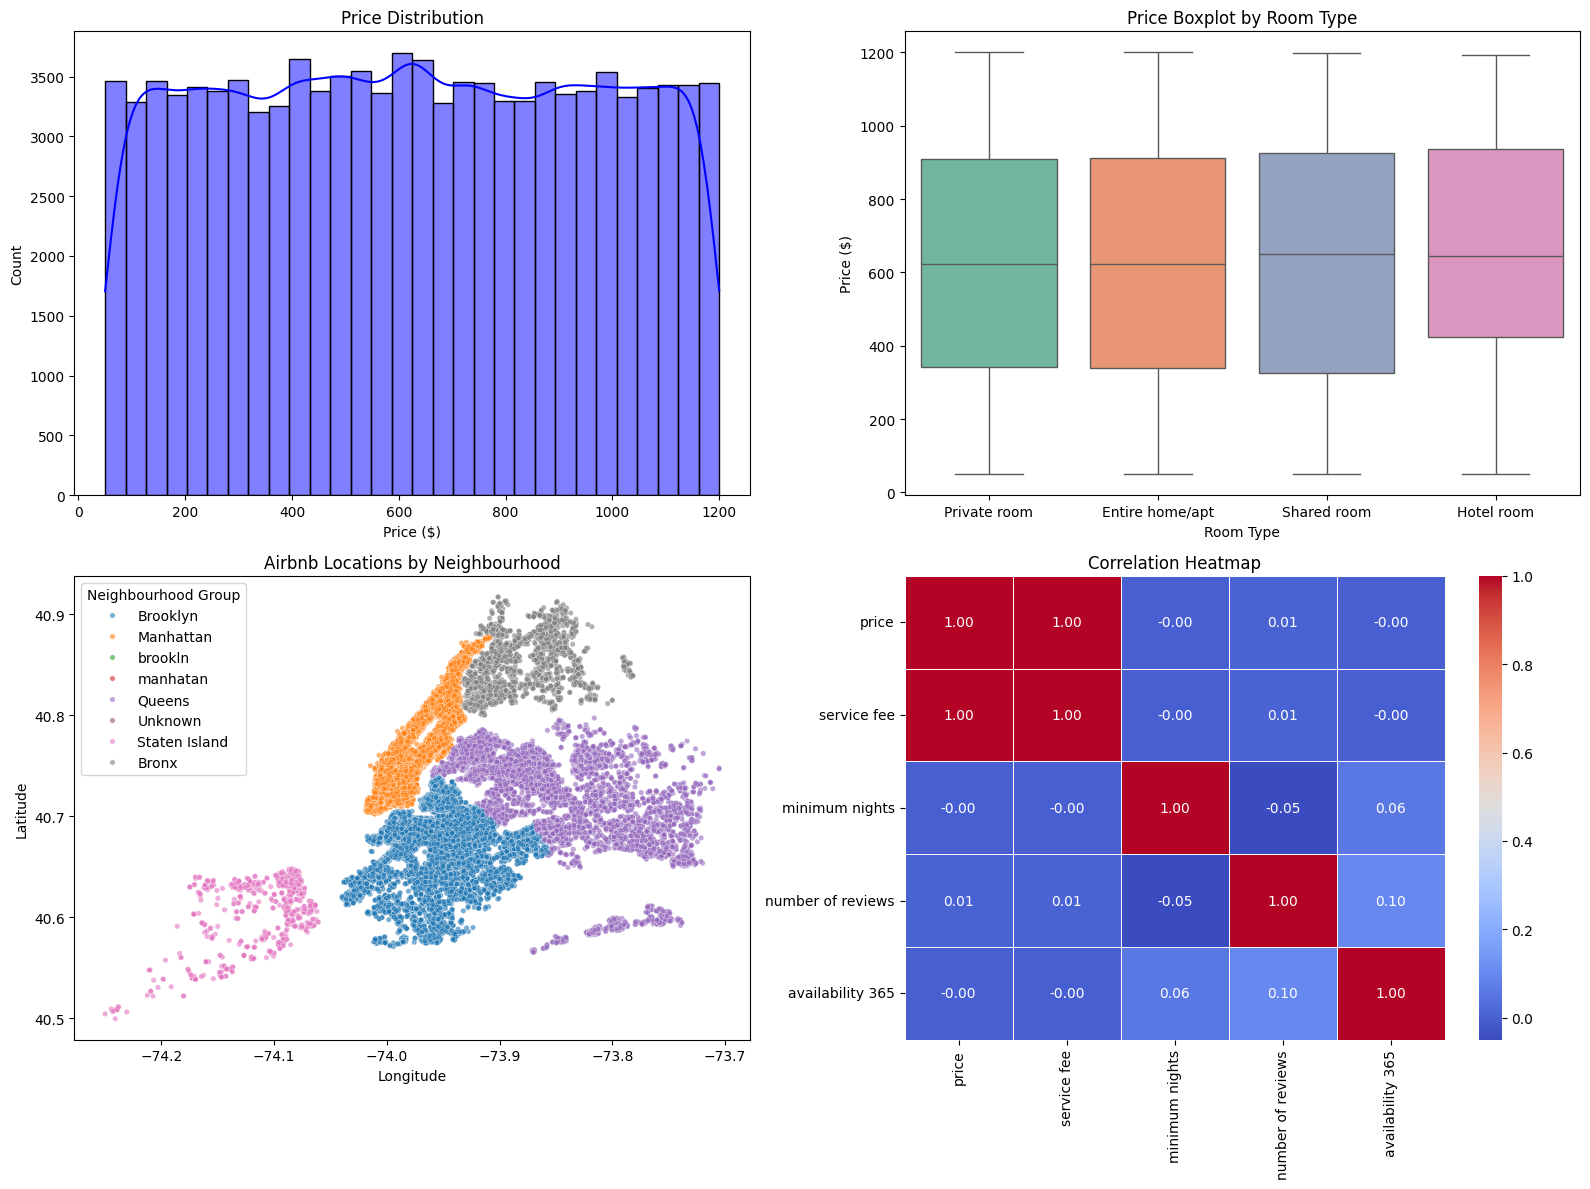

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# โหลดข้อมูล (ใช้ไฟล์ Cleaned ที่เป็นข้อความ เพื่อให้ชื่อบนกราฟอ่านง่ายขึ้น)
df = pd.read_csv("Airbnb_Cleaned_Data.csv", low_memory=False)

plt.figure(figsize=(16, 12))

#  Histogram (การกระจายตัวของราคา)
plt.subplot(2, 2, 1)
sns.histplot(df['price'], bins=30, kde=True, color='blue')
plt.title('Price Distribution')
plt.xlabel('Price ($)')
#กระจายตัวแบบค่อนข้างสม่ำเสมอ (Uniform) ในช่วงราคาตั้งแต่ประมาณ $50 ถึง $1,200
#  Boxplot (ราคาแยกตามประเภทห้อง)
plt.subplot(2, 2, 2)
sns.boxplot(x='room type', y='price', data=df, palette='Set2')
plt.title('Price Boxplot by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Price ($)')
#ราคาของห้องพักทั้ง 3 ประเภท (Entire home, Private room, Shared room) มีค่าเฉลี่ยและช่วงของราคาที่แทบจะใกล้เคียงกันหมดเลยในชุดข้อมูลนี้
#  Scatter plot (แผนที่พิกัดที่พัก)
plt.subplot(2, 2, 3)
sns.scatterplot(data=df, x='long', y='lat', hue='neighbourhood group', palette='tab10', s=15, alpha=0.6)
plt.title('Airbnb Locations by Neighbourhood')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Neighbourhood Group', loc='upper left')

#  Heatmap (ความสัมพันธ์ของข้อมูลตัวเลข)
plt.subplot(2, 2, 4)
num_cols = ['price', 'service fee', 'minimum nights', 'number of reviews', 'availability 365']
correlation = df[num_cols].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
#จะเห็นว่าสีแดงเข้มที่สุดคือความสัมพันธ์ระหว่าง price และ service fee (ได้ 1.00 เป๊ะ) ซึ่งเป็นการคอนเฟิร์มว่าสองตัวแปรนี้เกี่ยวข้องกัน 100%
plt.tight_layout()
plt.show() # ใช้ plt.show() เพื่อให้รูปเด้งขึ้นมาในหน้าจอ

=== วิเคราะห์ Outlier สำหรับคอลัมน์: price ===



/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3640 (\N{THAI CHARACTER SARA U}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3604 (\N{THAI CHARACTER DO DEK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3635 (\N{THAI CHARACTER SARA AM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3654 (\N{THAI CHARACTER MAIYAMOK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, *

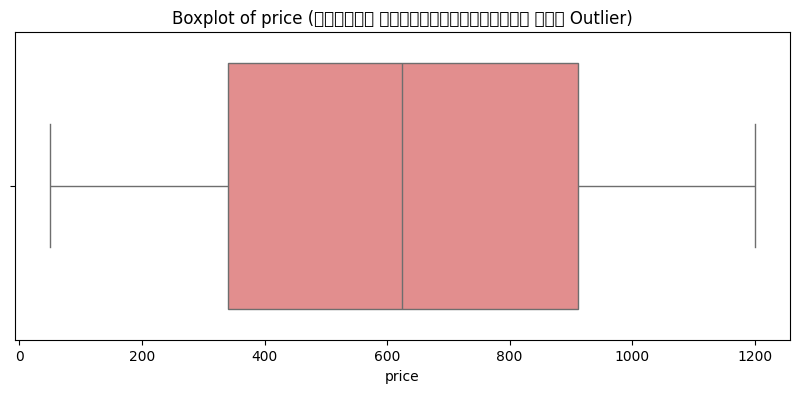

 ข้อมูลทางสถิติของ price:
 - ค่าขอบเขตล่าง (Lower Bound) ที่รับได้: -515.50
 - ค่าขอบเขตบน (Upper Bound) ที่รับได้:   1768.50

 สรุปผลการค้นหา Outlier:
พบข้อมูลที่เป็น Outlier ทั้งหมด: 0 แถว (จากทั้งหมด 102599 แถว)
คิดเป็นสัดส่วน: 0.00% ของข้อมูลทั้งหมด

ตัวอย่างข้อมูล Outlier 5 แถวแรก:
Empty DataFrame
Columns: [neighbourhood group, room type, price]
Index: []


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# โหลดข้อมูล
df = pd.read_csv("Airbnb_Cleaned_Data.csv", low_memory=False)

#  เลือกคอลัมน์ที่คุณต้องการเช็ค Outlier
col_to_check = 'price'

print(f"=== วิเคราะห์ Outlier สำหรับคอลัมน์: {col_to_check} ===\n")
plt.figure(figsize=(10, 4))
sns.boxplot(x=df[col_to_check], color='lightcoral')
plt.title(f'Boxplot of {col_to_check} (จุดดำๆ นอกเส้นหนวดกุ้ง คือ Outlier)')
plt.show()
#  คำนวณหาตัวเลขและจำนวนแถวด้วยหลักการ IQR
# หาค่า Q1 (เปอร์เซ็นไทล์ที่ 25) และ Q3 (เปอร์เซ็นไทล์ที่ 75)
Q1 = df[col_to_check].quantile(0.25)
Q3 = df[col_to_check].quantile(0.75)
IQR = Q3 - Q1
# คำนวณขอบเขตบนและล่าง (ค่าที่หลุดจากขอบเขตนี้จะถือว่าเป็น Outlier)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f" ข้อมูลทางสถิติของ {col_to_check}:")
print(f" - ค่าขอบเขตล่าง (Lower Bound) ที่รับได้: {lower_bound:.2f}")
print(f" - ค่าขอบเขตบน (Upper Bound) ที่รับได้:   {upper_bound:.2f}")
# ดึงข้อมูลแถวที่เป็น Outlier ออกมาดู
outliers = df[(df[col_to_check] < lower_bound) | (df[col_to_check] > upper_bound)]
print(f"\n สรุปผลการค้นหา Outlier:")
print(f"พบข้อมูลที่เป็น Outlier ทั้งหมด: {len(outliers)} แถว (จากทั้งหมด {len(df)} แถว)")
print(f"คิดเป็นสัดส่วน: {(len(outliers) / len(df)) * 100:.2f}% ของข้อมูลทั้งหมด")
# ดูตัวอย่างข้อมูลที่เป็น Outlier 5 แถวแรก
print("\nตัวอย่างข้อมูล Outlier 5 แถวแรก:")
print(outliers[['neighbourhood group', 'room type', col_to_check]].head())

In [5]:
import pandas as pd

# โหลดข้อมูล
df = pd.read_csv("Airbnb_Cleaned_Data.csv", low_memory=False)

# ลิสต์คอลัมน์ตัวเลขที่ควรตรวจสอบ
cols_to_check = [
    'minimum nights', #(กลุ่มที่เป็น "ของจริงในโลกธุรกิจ")
    'number of reviews', #(กลุ่มที่เป็น "ของจริงในโลกธุรกิจ")
    'reviews per month',
    'calculated host listings count', #(กลุ่มที่เป็น "ของจริงในโลกธุรกิจ")
    'availability 365'
]

print("===  รายงานสรุปการสแกนหา Outlier (วิธี IQR) ===\n")

for col in cols_to_check:
    # คำนวณ IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    # กำหนดขอบเขต
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # ดึงข้อมูล Outlier
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outliers_count = len(outliers)
    percent = (outliers_count / len(df)) * 100

    # แสดงผล
    print(f" คอลัมน์: {col}")
    print(f"   - ขอบเขตบนที่รับได้: {upper_bound:.2f}")
    if outliers_count > 0:
        print(f"   -  พบ Outlier: {outliers_count} แถว ({percent:.2f}%)")
    else:
        print(f"   -  ข้อมูลสะอาด ไม่มี Outlier")
    print("-" * 50)

===  รายงานสรุปการสแกนหา Outlier (วิธี IQR) ===

 คอลัมน์: minimum nights
   - ขอบเขตบนที่รับได้: 9.50
   -  พบ Outlier: 18394 แถว (17.93%)
--------------------------------------------------
 คอลัมน์: number of reviews
   - ขอบเขตบนที่รับได้: 73.50
   -  พบ Outlier: 11736 แถว (11.44%)
--------------------------------------------------
 คอลัมน์: reviews per month
   - ขอบเขตบนที่รับได้: 3.85
   -  พบ Outlier: 7125 แถว (6.94%)
--------------------------------------------------
 คอลัมน์: calculated host listings count
   - ขอบเขตบนที่รับได้: 3.50
   -  พบ Outlier: 17829 แถว (17.38%)
--------------------------------------------------
 คอลัมน์: availability 365
   - ขอบเขตบนที่รับได้: 665.50
   -  พบ Outlier: 1 แถว (0.00%)
--------------------------------------------------


In [6]:
import pandas as pd
import numpy as np

# โหลดข้อมูล
df = pd.read_csv("Airbnb_Cleaned_Data.csv", low_memory=False)

print("--- ก่อนจัดการ Outlier ---")
print(f"ค่าสูงสุดของ availability 365: {df['availability 365'].max()}")
print(f"ค่าต่ำสุดของ availability 365: {df['availability 365'].min()}")
print(f"ค่าสูงสุดของ minimum nights: {df['minimum nights'].max()}")

#  จัดการ availability 365 (ห้ามเกิน 365 และห้ามติดลบ)
# np.clip คือคำสั่งจำกัดเพดาน (ตบค่าให้อยู่ในช่วง 0 ถึง 365)
df['availability 365'] = np.clip(df['availability 365'], 0, 365)

#  จัดการ minimum nights (สมมติว่าเช่า Airbnb อย่างมากก็ไม่น่าเกิน 1 ปี หรือ 365 คืน)
# ใครที่ใส่ค่ามา 1,000 คืน จะถูกตบลงมาเหลือ 365 คืน
df['minimum nights'] = np.clip(df['minimum nights'], 1, 365) #(จัดการกับค่าติดลบ โดย ปรับค่าให้สมเหตุสมผล (Capping / Clipping))

print("\n--- หลังจัดการ Outlier (Capping) ---")
print(f"ค่าสูงสุดของ availability 365: {df['availability 365'].max()}")
print(f"ค่าต่ำสุดของ availability 365: {df['availability 365'].min()}")
print(f"ค่าสูงสุดของ minimum nights: {df['minimum nights'].max()}")

# เซฟทับไฟล์เดิมได้เลย
df.to_csv("Airbnb_Cleaned_Data.csv", index=False)
print("\n จัดการ Outlier ขยะเรียบร้อย และเซฟไฟล์แล้ว!")

--- ก่อนจัดการ Outlier ---
ค่าสูงสุดของ availability 365: 3677.0
ค่าต่ำสุดของ availability 365: -10.0
ค่าสูงสุดของ minimum nights: 5645.0

--- หลังจัดการ Outlier (Capping) ---
ค่าสูงสุดของ availability 365: 365.0
ค่าต่ำสุดของ availability 365: 0.0
ค่าสูงสุดของ minimum nights: 365.0

 จัดการ Outlier ขยะเรียบร้อย และเซฟไฟล์แล้ว!


#data preparation


In [7]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# โหลดข้อมูลที่ Clean
df = pd.read_csv("Airbnb_Cleaned_Data.csv", low_memory=False)

#  ข้อมูลวันที่ (last review) สาเหตุไม่เก็บคอลัมน์วันที่ เเยกคอลัม เพราะอัลกอริทึมส่วนใหญ่(เช่น Random Forest, XGBoost หรือ Linear Regression)
df['has_review'] = df['last review'].apply(lambda x: 0 if x == 'Not Available' else 1)
df['last review date'] = pd.to_datetime(df['last review'], errors='coerce')
df['last_review_year'] = df['last review date'].dt.year.fillna(0).astype(int)
df = df.drop(columns=['last review', 'last review date'])
#จัดการข้อมูลวันที่
#สร้างคอลัมน์ has_review: ดึงข้อมูล มาจาก คอลัม last review ถ้าเคยมีคนรีวิวให้เป็น 1 ถ้าเป็น Not Available ให้เป็น 0
#สร้างคอลัมน์ last_review_year: ดึงข้อมูล มาจาก คอลัม last review เฉพาะ "ปีที่รีวิว" (เช่น 2021, 2022) (ถ้าไม่มีรีวิว จะใส่ค่า 0 ไว้)
#สร้างคอลัมน์ last review date ดึงข้อมูล มาจาก คอลัม last review  แปลงให้กลายเป็นประเภทข้อมูลแบบ Datetime (errors='coerce' )ถ้าเจอข้อความไหนที่แปลงเป็นวันที่ไม่ได้เปลี่ยนค่านั้นเป็นค่าว่าง หรือ Not a Time


df['instant_bookable'] = df['instant_bookable'].astype(str).str.upper().map({'TRUE': 1, 'FALSE': 0, 'NAN': 0}).fillna(0).astype(int)
df['host_identity_verified'] = df['host_identity_verified'].astype(str).str.lower().map({'verified': 1, 'unconfirmed': 0}).fillna(0).astype(int)
#จัดการข้อมูลแบบสองทางเลือก
#instant_bookable: เปลี่ยน TRUE เป็น 1 และ FALSE เป็น 0
#host_identity_verified: เปลี่ยน verified เป็น 1 และ unconfirmed เป็น 0


# จัดการข้อมูล Ordinal (เรียงลำดับ)
policy_mapping = {'strict': 2, 'moderate': 1, 'flexible': 0}
df['cancellation_policy'] = df['cancellation_policy'].map(policy_mapping).fillna(0).astype(int)
#จากคอลัม cancellation_policy(การยกเลิก_นโยบาย) flexible (ยืดหยุ่นสุด) = 0,moderate (ปานกลาง) = 1,strict (เข้มงวดสุด) = 2



# จัดการข้อมูลหมวดหมู่ด้วย LabelEncoder ("การเปลี่ยนข้อมูลที่เป็นข้อความ  ให้กลายเป็นตัวเลข " โดยการกำหนดรหัสตัวเลขให้แต่ละหมวดหมู่แบบอัตโนมัติ)
#fit_transform
#fit ดูในคอลัมน์นั้นว่ามีคำศัพท์ที่ไม่ซ้ำกันทั้งหมดกี่คำ จากนั้นนำมา เรียงลำดับตามตัวอักษร
#Transform (แปลงร่าง): มันจะแจกหมายเลขรหัสให้แต่ละคำ โดยเริ่มตั้งแต่เลข 0, 1, 2, 3... ไปเรื่อยๆ จนครบ แล้วแทนที่ข้อความเดิมด้วยตัวเลขนั้นทันที
le = LabelEncoder()
df['room type'] = le.fit_transform(df['room type'].astype(str))
df['neighbourhood group'] = le.fit_transform(df['neighbourhood group'].astype(str))
df['neighbourhood'] = le.fit_transform(df['neighbourhood'].astype(str))
# room type: Private room = 0, Entire home = 1, Shared room = 2
#neighbourhood group (เขต): Bronx = 0, Brooklyn = 1, Manhattan = 2, Queens = 3, Staten Island = 4
#neighbourhood (ย่านย่อย): ถูกแปลงเป็นตัวเลข 0 ไปจนถึง 200 กว่าตามรายชื่อย่านครับ

# เซฟไฟล์พร้อมใช้งาน
df.to_csv("Airbnb_ML_Ready.csv", index=False)

#สร้างโมเดลทำนายราคา


In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# โหลดข้อมูล
df = pd.read_csv("Airbnb_ML_Ready.csv")

# *** จุดที่แก้ไข: ตัดทั้ง 'price' และ 'service fee' ทิ้งไป ***
X = df.drop(columns=['price', 'service fee'])
y = df['price']

# แบ่งข้อมูล 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# รวบรวมโมเดล
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    "Gradient Boosting": HistGradientBoostingRegressor(max_iter=100, max_depth=10, learning_rate=0.1, random_state=42)
}

# รันและดูผลลัพธ์
print("--- ผลลัพธ์การทายราคา (แบบไม่มี Service Fee ช่วยใบ้) ---\n")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"[{name}]")
    print(f" -> ทายราคาคลาดเคลื่อนเฉลี่ย (MAE): ${mae:.2f}")
    print(f" -> ความแม่นยำรวม (R2): {r2:.4f}\n")

--- ผลลัพธ์การทายราคา (แบบไม่มี Service Fee ช่วยใบ้) ---

[Linear Regression]
 -> ทายราคาคลาดเคลื่อนเฉลี่ย (MAE): $285.45
 -> ความแม่นยำรวม (R2): -0.0002

[Decision Tree]
 -> ทายราคาคลาดเคลื่อนเฉลี่ย (MAE): $284.91
 -> ความแม่นยำรวม (R2): -0.0045

[Random Forest]
 -> ทายราคาคลาดเคลื่อนเฉลี่ย (MAE): $276.08
 -> ความแม่นยำรวม (R2): 0.0611

[Gradient Boosting]
 -> ทายราคาคลาดเคลื่อนเฉลี่ย (MAE): $282.82
 -> ความแม่นยำรวม (R2): 0.0156



#ทำนายกลุ่มราคาที่พัก (Price Category) Low, Medium, High
เเบ่งกลุ่มเป็น 3 กลุ่ม

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

#  โหลดข้อมูล
df = pd.read_csv("Airbnb_ML_Ready.csv")

#  สร้างคอลัมน์ใหม่: แบ่งกลุ่มราคาเป็น 3 ระดับ (Low, Medium, High)
df['price_category'] = pd.qcut(df['price'], q=3, labels=['Low', 'Medium', 'High'])

#  กำหนด X และ y (*** จุดที่แก้ไข: ตัด service fee ทิ้งไปพร้อมกับ price ***)
X = df.drop(columns=['price', 'price_category', 'service fee'])
y = df['price_category']

#  แบ่งข้อมูล 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#  รวบรวมโมเดล
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    "Gradient Boosting": HistGradientBoostingClassifier(max_iter=100, max_depth=10, learning_rate=0.1, random_state=42)
}

#  รันและดูผลลัพธ์
for name, model in models.items():
    print(f"==================================================")
    print(f"กำลังรันโมเดล: [{name}] (แบบไม่มี Service fee)...")

    # เทรนโมเดล
    model.fit(X_train, y_train)

    # ทำนายผล
    y_pred = model.predict(X_test)

    # แสดงผลลัพธ์
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}\n")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print(f"==================================================\n")

กำลังรันโมเดล: [Logistic Regression] (แบบไม่มี Service fee)...


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.3409

Classification Report:
              precision    recall  f1-score   support

        High       0.33      0.33      0.33      6767
         Low       0.35      0.43      0.39      6893
      Medium       0.34      0.26      0.30      6860

    accuracy                           0.34     20520
   macro avg       0.34      0.34      0.34     20520
weighted avg       0.34      0.34      0.34     20520


กำลังรันโมเดล: [Decision Tree] (แบบไม่มี Service fee)...
Accuracy: 0.3452

Classification Report:
              precision    recall  f1-score   support

        High       0.35      0.30      0.32      6767
         Low       0.35      0.29      0.32      6893
      Medium       0.34      0.44      0.39      6860

    accuracy                           0.35     20520
   macro avg       0.35      0.35      0.34     20520
weighted avg       0.35      0.35      0.34     20520


กำลังรันโมเดล: [Random Forest] (แบบไม่มี Service fee)...
Accuracy: 0.5564

Classification Report:

#ทำนายกลุ่มราคาที่พัก (Price Category) ถูก หรือ เเพง

เปลี่ยนเป็นแบ่งกลุ่มราคาแค่ 2 ระดับ ถูก หรือ เเพง

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

#  โหลดข้อมูล
df = pd.read_csv("Airbnb_ML_Ready.csv")

#  ปรับใหม่: แบ่งกลุ่มราคาแค่ 2 ระดับ (หั่นครึ่ง 50/50)
df['price_category'] = pd.qcut(df['price'], q=2, labels=['Low', 'High'])

#  กำหนด X และ y (ตัด price และ service fee ทิ้ง)
X = df.drop(columns=['price', 'price_category', 'service fee'])
y = df['price_category']

#  แบ่งข้อมูล 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#  คัดมาเฉพาะโมเดลตัวท็อป 2 ตัวที่เก่งที่สุด
models = {
    "Random Forest (ปรับลด 2 กลุ่ม)": RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    "Gradient Boosting (ปรับลด 2 กลุ่ม)": HistGradientBoostingClassifier(max_iter=100, max_depth=10, learning_rate=0.1, random_state=42)
}

#  รันและดูผลลัพธ์
for name, model in models.items():
    print(f"==================================================")
    print(f"กำลังรันโมเดล: [{name}]...")

    # เทรนโมเดล
    model.fit(X_train, y_train)

    # ทำนายผล
    y_pred = model.predict(X_test)

    # แสดงผลลัพธ์
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}\n")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print(f"==================================================\n")

กำลังรันโมเดล: [Random Forest (ปรับลด 2 กลุ่ม)]...
Accuracy: 0.6425

Classification Report:
              precision    recall  f1-score   support

        High       0.65      0.61      0.63     10212
         Low       0.63      0.68      0.66     10308

    accuracy                           0.64     20520
   macro avg       0.64      0.64      0.64     20520
weighted avg       0.64      0.64      0.64     20520


กำลังรันโมเดล: [Gradient Boosting (ปรับลด 2 กลุ่ม)]...
Accuracy: 0.5495

Classification Report:
              precision    recall  f1-score   support

        High       0.55      0.52      0.54     10212
         Low       0.55      0.58      0.56     10308

    accuracy                           0.55     20520
   macro avg       0.55      0.55      0.55     20520
weighted avg       0.55      0.55      0.55     20520




In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

#  โหลดข้อมูล
df = pd.read_csv("Airbnb_ML_Ready.csv")

#  แบ่ง 2 กลุ่มราคา (ตัด price, price_category, service fee ทิ้ง)
df['price_category'] = pd.qcut(df['price'], q=2, labels=['Low', 'High'])
X = df.drop(columns=['price', 'price_category', 'service fee'])
y = df['price_category']

#  แบ่งข้อมูล Train / Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# . เทรนโมเดล
rf_model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

#  ดึงค่า Feature Importance
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance (%)': rf_model.feature_importances_ * 100
}).sort_values(by='Importance (%)', ascending=False)

print("--- 10 ปัจจัยที่มีผลต่อราคาที่พักมากที่สุด ---")
print(feature_importances.head(10).round(2).to_string(index=False))

--- 10 ปัจจัยที่มีผลต่อราคาที่พักมากที่สุด ---
                       Feature  Importance (%)
                          long           14.26
                           lat           13.96
             reviews per month           10.95
              availability 365           10.15
             number of reviews            9.15
             Construction year            8.14
                 neighbourhood            6.83
                minimum nights            5.39
calculated host listings count            4.66
            review rate number            4.25


In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier #  เพิ่ม Import XGBoost

# โหลดข้อมูล
df = pd.read_csv("Airbnb_ML_Ready.csv")

# ปรับใหม่: แบ่งกลุ่มราคาแค่ 2 ระดับ (หั่นครึ่ง 50/50)
#  ปรับ labels เป็น [0, 1] เพื่อให้ XGBoost ยอมรับ (0=Low, 1=High)
df['price_category'] = pd.qcut(df['price'], q=2, labels=[0, 1])

# กำหนด X และ y (ตัด price และ service fee ทิ้ง)
X = df.drop(columns=['price', 'price_category', 'service fee'])
y = df['price_category']

# แบ่งข้อมูล 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# คัดมาเฉพาะโมเดลตัวท็อป
models = {
    "Random Forest (ปรับลด 2 กลุ่ม)": RandomForestClassifier(
        n_estimators=100, max_depth=15, random_state=42, n_jobs=-1
    ),
    "Gradient Boosting (ปรับลด 2 กลุ่ม)": HistGradientBoostingClassifier(
        max_iter=100, max_depth=10, learning_rate=0.1, random_state=42
    ),
    # 3. เพิ่ม XGBoost Classifier (ตั้งค่าให้สูสีกับ Gradient Boosting ตัวบน)
    "XGBoost (ปรับลด 2 กลุ่ม)": XGBClassifier(
        n_estimators=100, max_depth=10, learning_rate=0.1, random_state=42, n_jobs=-1, eval_metric='logloss'
    )
}

# รันและดูผลลัพธ์
for name, model in models.items():
    print(f"==================================================")
    print(f"กำลังรันโมเดล: [{name}]...")

    # เทรนโมเดล
    model.fit(X_train, y_train)

    # ทำนายผล
    y_pred = model.predict(X_test)

    # แสดงผลลัพธ์
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}\n")
    print("Classification Report:")

กำลังรันโมเดล: [Random Forest (ปรับลด 2 กลุ่ม)]...
Accuracy: 0.6425

Classification Report:
กำลังรันโมเดล: [Gradient Boosting (ปรับลด 2 กลุ่ม)]...
Accuracy: 0.5490

Classification Report:
กำลังรันโมเดล: [XGBoost (ปรับลด 2 กลุ่ม)]...
Accuracy: 0.6395

Classification Report:


In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import time

#  โหลดข้อมูลและเตรียม 2 กลุ่มราคา (ตัด price, price_category, service fee ทิ้ง)
df = pd.read_csv("Airbnb_ML_Ready.csv")
df['price_category'] = pd.qcut(df['price'], q=2, labels=['Low', 'High'])

X = df.drop(columns=['price', 'price_category', 'service fee'])
y = df['price_category']

#  แบ่งข้อมูล Train 80% / Test 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#  กำหนดตัวแปรส่วนผสมที่ต้องการสุ่มหา (Parameter Grid)
param_grid = {
    'n_estimators': [100, 200, 300],       # ลองจำนวนต้นไม้ 3 แบบ
    'max_depth': [10, 15, 20],             # ลองความลึก 3 แบบ
    'min_samples_split': [2, 5]            # ลองกฎการแตกกิ่ง 2 แบบ
}

#  เรียกใช้ RandomForest และ GridSearchCV
rf = RandomForestClassifier(random_state=42, n_jobs=-1) # n_jobs=-1 คือสั่งให้ใช้ CPU ทุกคอร์ที่มีเพื่อความเร็ว

# cv=3 คือการทำ Cross-Validation แบ่งข้อสอบสลับกันเทส 3 รอบ เพื่อให้มั่นใจว่าไม่ได้ฟลุคแม่น
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, scoring='accuracy', verbose=2)

print("==================================================")
print(" กำลังเริ่มทำ GridSearchCV... (ขั้นตอนนี้อาจใช้เวลาหลายนาที ขึ้นอยู่กับสเปคคอมพิวเตอร์)")
start_time = time.time()

#  สั่งรันหาโมเดลที่ดีที่สุด!
grid_search.fit(X_train, y_train)

end_time = time.time()
print(f" ค้นหาส่วนผสมที่ดีที่สุดเสร็จสิ้น! (ใช้เวลาไป {round((end_time - start_time)/60, 2)} นาที)")
print("==================================================\n")

#  ประกาศผลแชมป์เปี้ยน (ส่วนผสมที่ทำให้แม่นที่สุด)
print(" ส่วนผสมที่ดีที่สุด (Best Parameters):")
print(grid_search.best_params_)
print("")

#  เอาโมเดลที่จูนแล้วมาทดสอบทำนายผล
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f" Accuracy ของโมเดลที่จูนแล้ว: {acc:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

 กำลังเริ่มทำ GridSearchCV... (ขั้นตอนนี้อาจใช้เวลาหลายนาที ขึ้นอยู่กับสเปคคอมพิวเตอร์)
Fitting 3 folds for each of 18 candidates, totalling 54 fits
[CV] END max_depth=10, min_samples_split=2, n_estimators=100; total time=   8.2s
[CV] END max_depth=10, min_samples_split=2, n_estimators=100; total time=   5.8s
[CV] END max_depth=10, min_samples_split=2, n_estimators=100; total time=   8.1s
[CV] END max_depth=10, min_samples_split=2, n_estimators=200; total time=  12.9s
[CV] END max_depth=10, min_samples_split=2, n_estimators=200; total time=  12.8s
[CV] END max_depth=10, min_samples_split=2, n_estimators=200; total time=  13.9s
[CV] END max_depth=10, min_samples_split=2, n_estimators=300; total time=  21.9s
[CV] END max_depth=10, min_samples_split=2, n_estimators=300; total time=  19.7s
[CV] END max_depth=10, min_samples_split=2, n_estimators=300; total time=  19.6s
[CV] END max_depth=10, min_samples_split=5, n_estimators=100; total time=   8.3s
[CV] END max_depth=10, min_samples_split=